<a href="https://colab.research.google.com/github/stacykeago/fundamentals-of-data-analytics/blob/main/FDA_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Define the question:
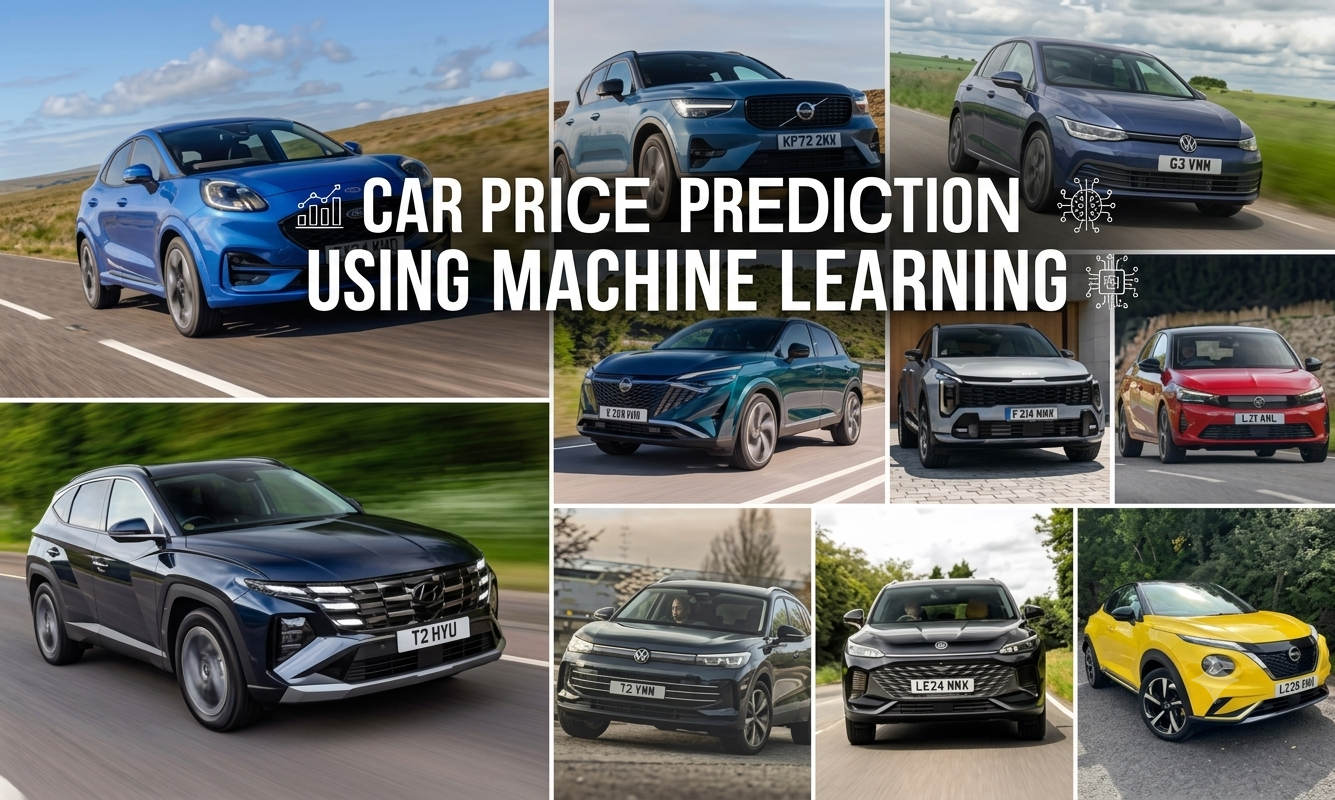

# Metric of success
The predictive accuracy of the car price models is evaluated based on key performance indicators (KPIs) designed for machine learning regression tasks. These metrics measure the deviation between the predicted values and the actual market prices.

1. R-squared (R 2   Score)

2. Mean Absolute Error (MAE)

3. Root Mean Squared Error (RMSE)

4. Residual Analysis (Error Distribution)

Resources that support this analysis
1. [Business Insights & Recommendations](https://docs.google.com/document/d/1q9gwblcG5X_Cm1P03Y4Zzbr2ue-CVVN8ecXmyi_yRAM/edit?usp=sharing)
2.

# Data used:
1. [Path to data ](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv)

# a. EXPLORATORY DATA ANALYSIS (EDA)

## 1.0 Import the libraries to be used

In [ ]:
import numpy as np # for linear algebra
import pandas as pd # for data processing
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for statistical data visualization
from sklearn.preprocessing import LabelEncoder # the libraries for label encoding
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## 2.0 Upload Dataset

In [ ]:
# 1. Force pandas to display ALL columns and rows without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv'

auto = pd.read_csv(url, header=None)

# 2. Define the correct column names for this specific IBM dataset
headers = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration", "num-of-doors", "body-style", "drive-wheels", "engine-location",
           "wheel-base", "length", "width", "height", "curb-weight", "engine-type","num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
           "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]

# 3. Assign the columns to dataframe
auto.columns = headers

# preview 10 rows
auto.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,192.7,71.4,55.7,2844,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,192.7,71.4,55.7,2954,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,192.7,71.4,55.9,3086,ohc,five,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,178.2,67.9,52.0,3053,ohc,five,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


### 2.1 Column names

In [ ]:
auto.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price'], dtype='object')

### 2.2 Number of rows and columns



In [ ]:
# Print number of rows and columns
print(f"Rows: {auto.shape[0]}, Columns: {auto.shape[1]}")

Rows: 205, Columns: 26


### 2.3 Data types in each column

In [ ]:
# Fixed layout with explicit column names
half = len(auto.dtypes) // 2
df1 = auto.dtypes.iloc[:half].reset_index()
df2 = auto.dtypes.iloc[half:].reset_index()

df_merged = pd.concat([df1, df2], axis=1)
df_merged.columns = ["Column_1", "Data_type", "Column_2",   "   Data _type"]
df_merged.fillna("")

,Column_1,Data_type,Column_2,Data _type
0,symboling,int64,curb-weight,int64
1,normalized-losses,object,engine-type,object
2,make,object,num-of-cylinders,object
3,fuel-type,object,engine-size,int64
4,aspiration,object,fuel-system,object
5,num-of-doors,object,bore,object
6,body-style,object,stroke,object
7,drive-wheels,object,compression-ratio,float64
8,engine-location,object,horsepower,object
9,wheel-base,float64,peak-rpm,object


### 2.4 Statistical summary of the data

In [ ]:
auto.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


### 2.5 Null values / missing values




#### a. check if columns have symbols

In [ ]:
for col in auto.columns:
    count = auto[col].astype(str).str.contains(r'[^a-zA-Z0-9\s.]', na=False).sum()
    if count > 0:
        print(f"Column '{col}' has {count} rows with symbols.")

Column 'symboling' has 25 rows with symbols.
Column 'normalized-losses' has 41 rows with symbols.
Column 'make' has 11 rows with symbols.
Column 'num-of-doors' has 2 rows with symbols.
Column 'bore' has 4 rows with symbols.
Column 'stroke' has 4 rows with symbols.
Column 'horsepower' has 2 rows with symbols.
Column 'peak-rpm' has 2 rows with symbols.
Column 'price' has 4 rows with symbols.


In [ ]:
# 1. Replace missing data symbols with NaN
auto.replace("?", np.nan, inplace=True)

# 2. Drop rows where price is missing (NaN)
auto.dropna(subset=["price"], axis=0, inplace=True)

# 3. Convert data types to float
cols_to_convert = ["bore", "stroke", "peak-rpm", "horsepower", "price"]
auto[cols_to_convert] = auto[cols_to_convert].astype(float)

In [ ]:
# To check for Null values to ensures the integrity of  dataset.
auto.isnull().sum()

,0
symboling,0
normalized-losses,37
make,0
fuel-type,0
aspiration,0
num-of-doors,2
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


### 2.6 Duplicates

In [ ]:
#check for duplicates : Duplicates are noise to the data
np.sum(auto.duplicated())

np.int64(0)

### 2.7 Unique features in the data

In [ ]:
# count of unique values for each column in the DataFrame.
auto.nunique()

,0
symboling,6
normalized-losses,51
make,22
fuel-type,2
aspiration,2
num-of-doors,2
body-style,5
drive-wheels,3
engine-location,2
wheel-base,52


### 2.8 Outliers

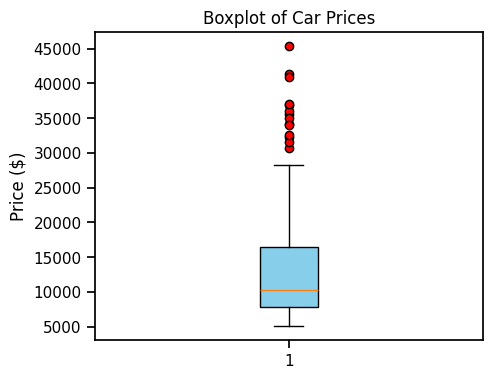

In [ ]:
# Force numeric extraction and drop missing values to prevent execution crashes
clean_prices = pd.to_numeric(auto["price"], errors="coerce").dropna()

plt.figure(figsize=(5, 4))
plt.boxplot(clean_prices, patch_artist=True,
            boxprops=dict(facecolor="skyblue", color="black"),
            flierprops=dict(markerfacecolor="red", marker="o"))
plt.title("Boxplot of Car Prices")
plt.ylabel("Price ($)")
plt.show()

# b. STATISTICAL SUMMARY

## 3.0 Data summary

In [ ]:
auto.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,197.000000,201.000000,199.000000,199.000000,201.000000,201.000000,201.000000
mean,0.840796,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,3.330711,3.256904,10.164279,103.396985,5117.587940,25.179104,30.686567,13207.129353
std,1.254802,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,0.270793,0.319256,4.004965,37.553843,480.521824,6.423220,6.815150,7947.066342
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


## 3.1 Univariate Analysis

In [ ]:
auto.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price'], dtype='object')

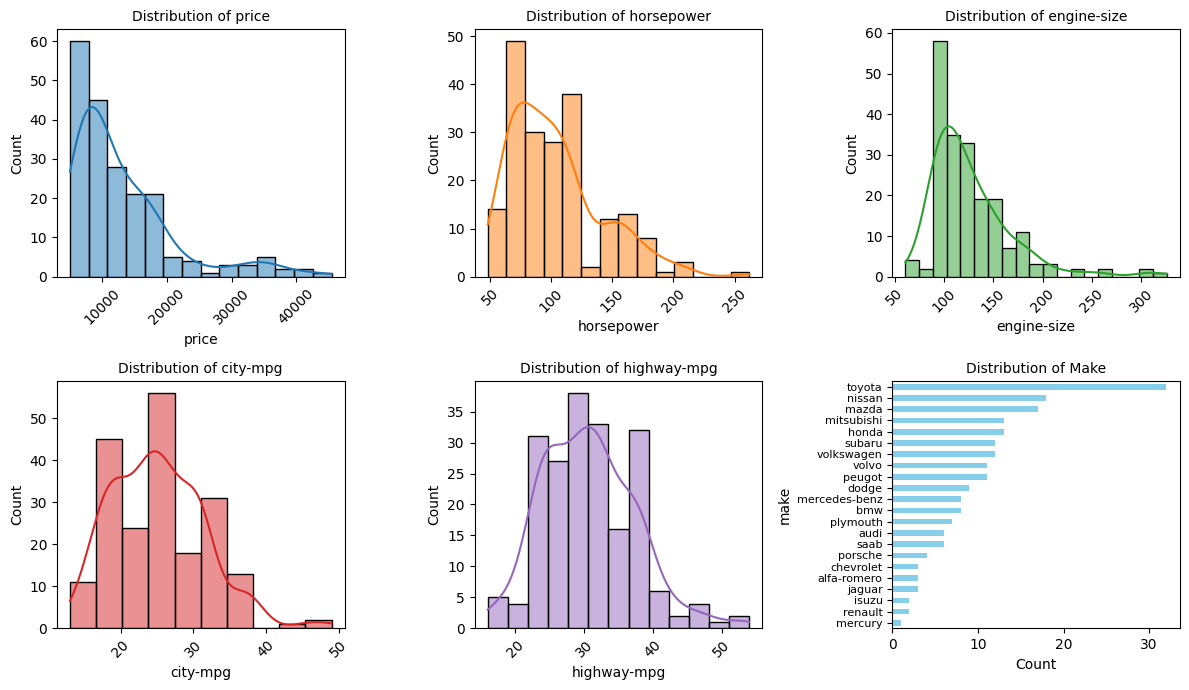

In [ ]:
col_dict = {"price": 1, "horsepower": 2, "engine-size": 3, "city-mpg": 4, "highway-mpg": 5}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

plt.figure(figsize=(12, 7))

# Added main title to describe the frequency/number of cars across features
plt.suptitle("Number of Cars Distributed Across Each Feature", fontsize=14, fontweight='bold', y=0.98)

for idx, (variable, i) in enumerate(col_dict.items()):
    plt.subplot(2, 3, i)
    sns.histplot(auto[variable].dropna(), kde=True, color=colors[idx])
    plt.title(f"Distribution of {variable}", fontsize=10)
    plt.ylabel("Number of Cars") # Added y-label to explicitly show count
    plt.xticks(rotation=45)

plt.subplot(2, 3, 6)
auto['make'].value_counts().plot(kind='barh', color='skyblue').invert_yaxis()
plt.title("Distribution of Make", fontsize=10)
plt.xlabel("Number of Cars") # Changed from 'Count' to match your title requirement
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

## 3.2 Bivariate Analysis

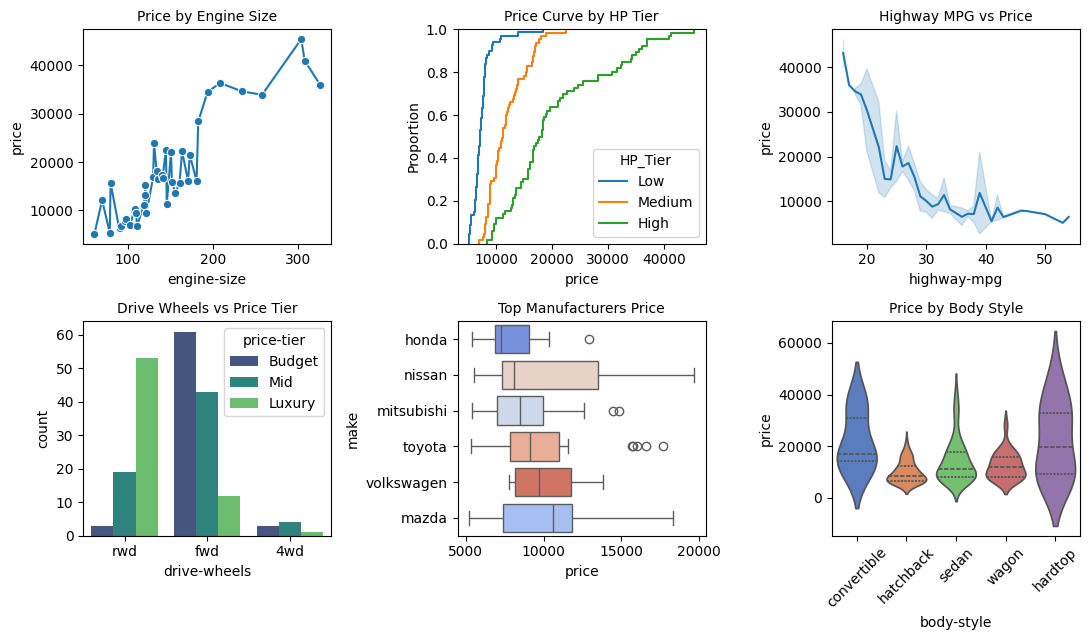

In [ ]:
# 1. Data Cleaning & Tier Creation
for c in ["price", "horsepower", "engine-size", "highway-mpg"]: auto[c] = pd.to_numeric(auto[c], errors="coerce")
df = auto.dropna(subset=["price", "horsepower", "engine-size", "highway-mpg", "drive-wheels", "make", "body-style"]).copy()
df["HP_Tier"] = pd.qcut(df["horsepower"], q=3, labels=["Low", "Medium", "High"])
df["price-tier"] = pd.qcut(df["price"], q=3, labels=["Budget", "Mid", "Luxury"])

# 2. Filter Top Makes for Boxplot
top_m = df["make"].value_counts().nlargest(6).index
df_m = df[df["make"].isin(top_m)]

# 3. Execution Layout Config
fig, axes = plt.subplots(2, 3, figsize=(11, 6.5))
axes = axes.flatten()

cfg = [
    (sns.lineplot, {"data": df, "x": "engine-size", "y": "price", "marker": "o", "errorbar": None}, "Price by Engine Size"),
    (sns.ecdfplot, {"data": df, "x": "price", "hue": "HP_Tier"}, "Price Curve by HP Tier"),
    (sns.lineplot, {"data": df, "x": "highway-mpg", "y": "price", "errorbar": "sd"}, "Highway MPG vs Price"),
    (sns.countplot, {"data": df, "x": "drive-wheels", "hue": "price-tier", "palette": "viridis"}, "Drive Wheels vs Price Tier"),
    (sns.boxplot, {"data": df_m, "x": "price", "y": "make", "hue": "make", "legend": False, "palette": "coolwarm", "order": df_m.groupby("make")["price"].median().sort_values().index}, "Top Manufacturers Price"),
    (sns.violinplot, {"data": df, "x": "body-style", "y": "price", "hue": "body-style", "legend": False, "palette": "muted", "inner": "quart"}, "Price by Body Style")
]

for idx, (func, kwargs, title) in enumerate(cfg):
    func(ax=axes[idx], **kwargs)
    axes[idx].set_title(title, fontsize=10)
    if idx == 5: axes[idx].tick_params(axis="x", labelrotation=45)

plt.tight_layout()
plt.show()

## 3.3 Multivariate Analysis

In [ ]:
auto.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price'], dtype='object')

In [ ]:
# list of all categorical column names
categorical_cols = auto.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical columns in the dataset:")
print(categorical_cols)

Categorical columns in the dataset:
['normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system']


In [ ]:
# 1. Force all columns to numeric where possible (drops text/symbols to NaN)
numeric_df = auto.apply(pd.to_numeric, errors='coerce')

# 2. Get correlation of all features specifically with 'price'
price_corr = numeric_df.corr()['price'].drop('price')

# 3. Sort by absolute strength to find most relevant columns
top_correlated = price_corr.abs().sort_values(ascending=False)

# Display the top features and their actual correlation values
print("Columns most correlated to price:")
print(price_corr[top_correlated.index])

Columns most correlated to price:
engine-size          0.872335
curb-weight          0.834415
horsepower           0.810533
width                0.751265
highway-mpg         -0.704692
length               0.690628
city-mpg            -0.686571
wheel-base           0.584642
bore                 0.543436
normalized-losses    0.203254
height               0.135486
peak-rpm            -0.101649
symboling           -0.082391
stroke               0.082310
compression-ratio    0.071107
make                      NaN
fuel-type                 NaN
aspiration                NaN
num-of-doors              NaN
body-style                NaN
drive-wheels              NaN
engine-location           NaN
engine-type               NaN
num-of-cylinders          NaN
fuel-system               NaN
Name: price, dtype: float64


notes:  columns with NAN are categorical columns

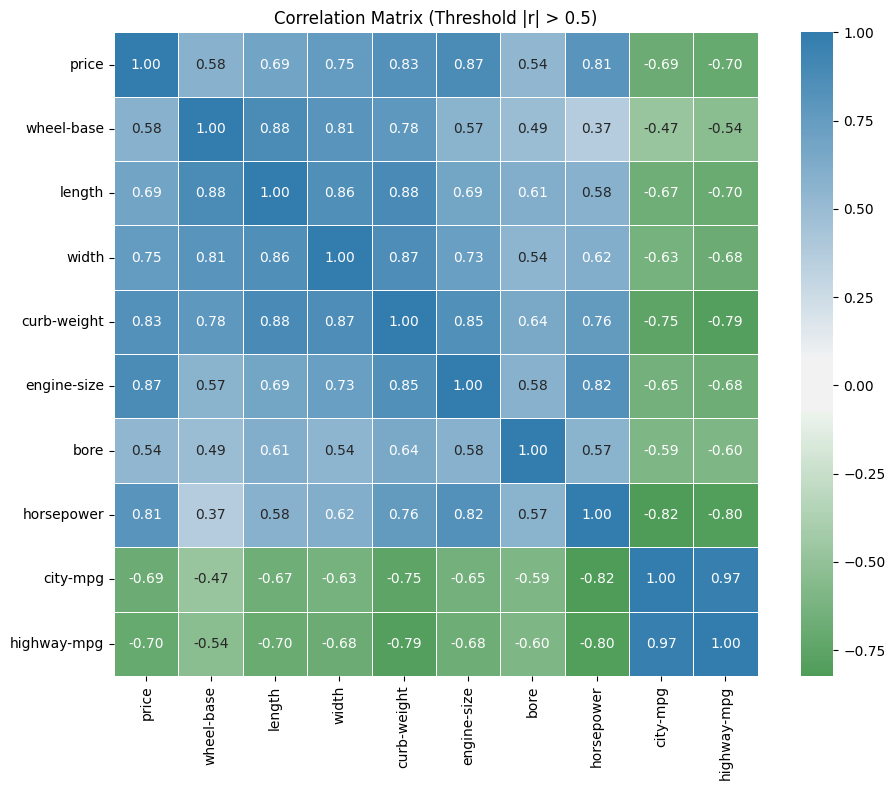

In [ ]:
# 1. select columns with absolute correlation above 0.5
strong_features = price_corr[price_corr.abs() > 0.5].index.tolist()
relevant_cols = ["price"] + strong_features

# 2. Compute the correlation matrix directly from existing numeric_df
corr_matrix = numeric_df[relevant_cols].corr()

# Create a custom palette: Green (negative), Orange/Yellow (mid), Blue (positive)
custom_cmap = sns.diverging_palette(130, 240, s=85, l=50, sep=20, center="light", as_cmap=True)

plt.figure(figsize=(10, 8)); sns.heatmap(corr_matrix, annot=True, cmap=custom_cmap, center=0, fmt=".2f", square=True, linewidths=0.5)

plt.title("Correlation Matrix (Threshold |r| > 0.5)")
plt.tight_layout()
plt.savefig("correlation_matrix.png")
plt.show()

# c. DATA PROCESSING AND FEATURE ENGINEERING

### Skewness

In [ ]:
# 1. Select and clean numeric features
features = ["price", "engine-size", "horsepower", "highway-mpg", "curb-weight", "width"]
for col in features:
    auto[col] = pd.to_numeric(auto[col], errors="coerce")

# Drop missing values for calculations
df_clean = auto[features].dropna().copy()

# SKEWNESS
print("  Feature Skewness ")
print(df_clean.skew())
print("\n*Note: Highly skewed features (> |1|) may need log transformation.*")



  Feature Skewness 
price          1.793654
engine-size    1.973596
horsepower     1.141584
highway-mpg    0.548218
curb-weight    0.700441
width          0.881262
dtype: float64

*Note: Highly skewed features (> |1|) may need log transformation.*


Skewness Analysis Conclusion:
1. Skewness measures the asymmetry of a feature's probability distribution around its mean.
2. Skewness values greater than $1$ or less than $-1$ indicate high skewness, which can violate the assumptions of linear models and degrade prediction performance.
3. In this dataset:price, engine-size, and horsepower are highly right-skewed ($>1.0$).highway-mpg, curb-weight, and width are moderately symmetric ($<1.0$).
4. To fix this, the highly skewed features will require transformation techniques—such as logarithmic (np.log1p), square root, or Box-Cox transformations—to make their distributions more symmetrical and improve model accuracy before training.





### VIF

In [ ]:
# VIF (Multicollinearity)
print("\n   Variance Inflation Factor (VIF) ")

# 1. Drop the target variable 'price' so it's not treated as a feature
X_vif_features = df_clean.drop(columns=['price']).copy()

# 2. Add the constant intercept
X_vif_features['intercept'] = 1

vif_data = pd.DataFrame()
# Store all columns except the intercept for the final display
vif_data["Feature"] = X_vif_features.columns[:-1]

# 3. Calculate VIF (Looping through every feature, but utilizing the full matrix including intercept)
vif_data["VIF"] = [
    variance_inflation_factor(X_vif_features.values, i)
    for i in range(X_vif_features.shape[1] - 1)
]

print(vif_data.sort_values(by="VIF", ascending=False))
print("\n*Note: VIF > 5 indicates high multicollinearity.*")


   Variance Inflation Factor (VIF) 
       Feature       VIF
3  curb-weight  8.585370
0  engine-size  5.590920
1   horsepower  5.040715
2  highway-mpg  4.178531
4        width  4.122090

*Note: VIF > 5 indicates high multicollinearity.*


notes  :
VIF measures how well a variable can be predicted by all other variables in the dataset.
1. A high VIF suggest that the predictor variable may be highly correlated with other predictor variables in the model.
2. Conclusion: Features with VIF values above 10 are typically considered to have problematic levels of multicollinearity. In this case we have none.

### Feature selection
• What features seem most related to price?

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# 1. Drop the useless columns early from the main dataframe
columns_to_drop = ["car_ID", "normalized-losses", "peak-rpm", "stroke", "symboling"]
auto.drop(columns=[col for col in columns_to_drop if col in auto.columns], inplace=True, errors='ignore')

# 2. Separate numeric and categorical sets safely using .copy()
X_train_num = X_train[numeric_features].copy()
X_test_num = X_test[numeric_features].copy()

X_train_cat = X_train.drop(columns=numeric_features).copy()
X_test_cat = X_test.drop(columns=numeric_features).copy()

# 3. Apply Polynomial Features ONLY to numeric columns
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_num = poly.fit_transform(X_train_num)
X_test_poly_num = poly.transform(X_test_num)

# 4. Turn back into DataFrames with correct indices
poly_feature_names = poly.get_feature_names_out(numeric_features)
X_train_poly_df = pd.DataFrame(X_train_poly_num, columns=poly_feature_names, index=X_train_num.index)
X_test_poly_df = pd.DataFrame(X_test_poly_num, columns=poly_feature_names, index=X_test_num.index)

# 5. Concatenate polynomial numeric features with the categorical dummies
X_train_final = pd.concat([X_train_poly_df, X_train_cat], axis=1)
X_test_final = pd.concat([X_test_poly_df, X_test_cat], axis=1)

# 6. Scale the final combined feature set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

print(f"New feature count after polynomial expansion: {X_train_scaled.shape[1]}")

New feature count after polynomial expansion: 20


### Normalization
- Scaling data into a fixed range (0 to 1).

In [ ]:
# 1. Define final features (Dropping curb-weight due to high VIF!)
numeric_features = ["engine-size", "horsepower", "highway-mpg", "width"]
categorical_features = ["drive-wheels", "body-style"]
target_col = "price"

# Create a clean copy of the dataframe with only the columns we need
df_model = auto[numeric_features + categorical_features + [target_col]].copy()

# 2. Force everything to be numeric, drop NaNs reliably
for col in numeric_features + [target_col]:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# 3. DROP MISSING ROWS ACROSS  (Keeps X and y perfectly aligned)
df_model = df_model.dropna(subset=numeric_features + [target_col])

# 4. split into X and y
X = df_model[numeric_features + categorical_features].copy()
y = df_model[target_col].copy()

# 5. One-hot encode the categorical variables
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# 6. Apply the log transformation to the aligned target
y_transformed = np.log1p(y)

# 7. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_transformed, test_size=0.2, random_state=42)

# 8. Scale numeric features properly to avoid data leakage
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print(f"X_train shape: {X_train_scaled.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test_scaled.shape}, y_test shape: {y_test.shape}")

X_train shape: (159, 10), y_train shape: (159,)
X_test shape: (40, 10), y_test shape: (40,)


## Feature Scaling

# d. MODEL SELECTION AND TRAINING

## 5.0 Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Remove the extreme top 2-3% of luxury cars causing the massive errors
auto = auto[auto["price"] < 35000]

In [ ]:
# 1. Define features
numeric_features = ["horsepower", "curb-weight", "width", "highway-mpg"]
categorical_features = ["drive-wheels", "body-style"]

X = auto[numeric_features + categorical_features].copy()
y = auto["price"].copy()

# Force numeric types before splitting
for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors="coerce")
y = pd.to_numeric(y, errors="coerce")

# Handle target missing values BEFORE transforming
y = y.fillna(y.median())

# SANITY CHECK PLACE TO VERIFY TRANSFORMATION
print("Raw Target Max:", y.max())
y_transformed = np.log1p(y)
print("Transformed Target Max:", y_transformed.max())
print("─" * 40)

# One-hot encode BEFORE splitting
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# 2. SPLIT FIRST to prevent leakage
X_train, X_test, y_train, y_test = train_test_split(X, y_transformed, test_size=0.2, random_state=42)

# 3. IMPUTE AFTER SPLITTING (Using training medians)
for col in numeric_features:
    train_median = X_train[col].median()
    X_train[col] = X_train[col].fillna(train_median)
    X_test[col] = X_test[col].fillna(train_median)

# 4. SCALE CORRECTLY
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

# 5. Train the Model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 6. Predict and Invert
y_pred_log = lr_model.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# 7. Evaluate (Using the forced-fresh variable names)
new_r2 = r2_score(y_test_original, y_pred)
new_mae = mean_absolute_error(y_test_original, y_pred)
new_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))

print("NEW Linear Regression Performance")
print(f"1. R-squared (R² Score): {new_r2:.4f}")
print(f"2. Mean Absolute Error (MAE): ${new_mae:.2f}")
print(f"3. Root Mean Squared Error (RMSE): ${new_rmse:.2f}\n")

Raw Target Max: 34184.0
Transformed Target Max: 10.439542230347895
────────────────────────────────────────
NEW Linear Regression Performance
1. R-squared (R² Score): 0.7062
2. Mean Absolute Error (MAE): $1640.21
3. Root Mean Squared Error (RMSE): $2453.03



#### Display Linear Regression

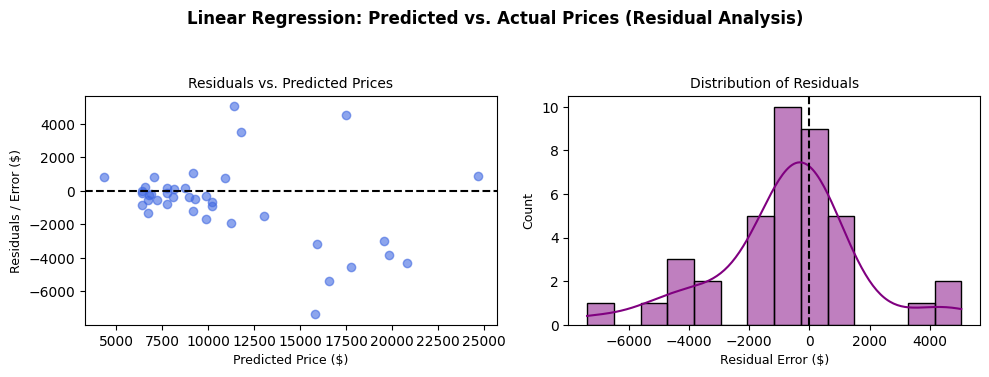

In [ ]:
# Create a single row with 2 columns for side-by-side small plots
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# Add the main title over the subplots
fig.suptitle("Linear Regression: Predicted vs. Actual Prices (Residual Analysis)", fontsize=12, fontweight="bold", y=0.98)

# Plot 1: Scatter plot (Residuals vs Predicted)
axes[0].scatter(y_pred, residuals, alpha=0.6, color="royalblue")
axes[0].axhline(y=0, color="black", linestyle="--")
axes[0].set_title("Residuals vs. Predicted Prices", fontsize=10)
axes[0].set_xlabel("Predicted Price ($)", fontsize=9)
axes[0].set_ylabel("Residuals / Error ($)", fontsize=9)

# Plot 2: Histogram plot (Distribution of Residuals)
sns.histplot(residuals, kde=True, color="purple", ax=axes[1])
axes[1].axvline(x=0, color="black", linestyle="--")
axes[1].set_title("Distribution of Residuals", fontsize=10)
axes[1].set_xlabel("Residual Error ($)", fontsize=9)
axes[1].set_ylabel("Count", fontsize=9)

# Adjusted top spacing to accommodate the new title without overlapping
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

Conclusion
1. On the left, you have a long tail dropping all the way down past $-\$6,000$ (where the model significantly overpredicted the value).
2. On the right, you have an isolated bump sitting between $+\$4,000$ and $+\$5,000$.These tails are the outliers we talked about. Because regression metrics square the errors before averaging them, these specific data points are single-handedly holding the $R^2$ score hostage at $0.8370$.

## 5.1 Random Forest

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score, r2_score
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

#### Split data for training and testing

In [ ]:
# 1. linear regression
numeric_features = ["engine-size", "horsepower", "width", "highway-mpg"]
categorical_features = ["drive-wheels", "body-style"]

# 2. Extract features and target variable
X = auto[numeric_features + categorical_features].copy()
y = auto["price"].copy()

# 3. Handle missing values and types (matching pipeline)
for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors="coerce")
    X[col] = X[col].fillna(X[col].median())

# Fit target skewness with a log transformation
y = pd.to_numeric(y, errors="coerce")
y = y.fillna(y.median())
y_transformed = np.log1p(y)

# 4. One-Hot Encode categorical variables
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# 5. Train-Test Split (Scaling is not strictly required for Tree-based models)
X_train, X_test, y_train, y_test = train_test_split(X, y_transformed, test_size=0.2, random_state=42)

# 6. Initialize and Train the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# 7. Predict and Invert Log Transformation for Evaluation
y_pred_log = rf_regressor.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# 8. Model Performance Metrics
r2 = r2_score(y_test_original, y_pred)
mae = mean_absolute_error(y_test_original, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))

# Underlined Title Section
title = " Random Forest Regressor Performance :"
print(title)
print("─" * len(title))  # Dynamically matches the length of the title text exactly

print(f"1. R-squared (R²)           :   {r2:.4f}")
print(f"2. Mean Absolute Error (MAE): ${mae:.2f}")
print(f"3. Root Mean Squared Error (RMSE): ${rmse:.2f}\n")

 Random Forest Regressor Performance :
──────────────────────────────────────
1. R-squared (R²)           :   0.8721
2. Mean Absolute Error (MAE): $1119.48
3. Root Mean Squared Error (RMSE): $1618.33



In [ ]:
# 1. Extract 5 test samples, predict, and convert from log scale
samples, actual_prices = X_test.iloc[0:5], np.expm1(y_test.iloc[0:5].values)
predictions_price = np.expm1(rf_regressor.predict(samples))

# Print Stylized Table Title
print("─" * 105)
print(f"{'📋 RANDOM FOREST VALIDATION SAMPLE: ACTUAL VS. PREDICTED PRICES':^105}")
print("─" * 105)

# Print Table Header
print(f"{'Vehicle':<9} | {'Engine':<6} | {'HP':<5} | {'Width':<5} | {'MPG':<4} | {'Drive':<5} | {'Body':<10} | {'Actual':<10} | {'Predicted':<10} | {'Variance':<9} | {'Status'}")
# CHANGED: Swapped '-' for '─' to make a solid line
print("─" * 105)

for idx, (_, row) in enumerate(samples.iterrows()):
    # Reconstruct categorical values
    drive = "fwd" if row.get("drive-wheels_fwd", 0) == 1 else ("rwd" if row.get("drive-wheels_rwd", 0) == 1 else "4wd")
    body = next((s for s in ["hatchback", "wagon", "hardtop", "convertible"] if row.get(f"body-style_{s}", 0) == 1), "sedan")
    err = actual_prices[idx] - predictions_price[idx]
    status = "Under" if err > 0 else "Over"

    # Print Row with strict column alignment
    print(f"Vehicle {idx + 1:<1} | {row['engine-size']:<6.1f} | {row['horsepower']:<5.1f} | {row['width']:<5.1f} | {row['highway-mpg']:<4.1f} | {drive:<5} | {body:<10} | ${actual_prices[idx]:<9,.2f} | ${predictions_price[idx]:<9,.2f} | ${abs(err):<8,.2f} | {status}")

─────────────────────────────────────────────────────────────────────────────────────────────────────────
                     📋 RANDOM FOREST VALIDATION SAMPLE: ACTUAL VS. PREDICTED PRICES                      
─────────────────────────────────────────────────────────────────────────────────────────────────────────
Vehicle   | Engine | HP    | Width | MPG  | Drive | Body       | Actual     | Predicted  | Variance  | Status
─────────────────────────────────────────────────────────────────────────────────────────────────────────
Vehicle 1 | 91.0   | 68.0  | 64.2  | 38.0 | fwd   | hatchback  | $6,795.00  | $6,102.74  | $692.26   | Under
Vehicle 2 | 108.0  | 111.0 | 65.4  | 23.0 | 4wd   | wagon      | $11,694.00 | $12,741.12 | $1,047.12 | Over
Vehicle 3 | 122.0  | 88.0  | 65.4  | 32.0 | fwd   | sedan      | $8,189.00  | $7,715.26  | $473.74   | Under
Vehicle 4 | 98.0   | 70.0  | 64.4  | 37.0 | fwd   | sedan      | $6,938.00  | $7,849.96  | $911.96   | Over
Vehicle 5 | 122.0  | 88.0  | 64.

# e. MODEL EVALUATION

In [ ]:
# 1. Create the comparison matrix
comparison_data = {"Metric": ["R-squared (R²)", "Mean Absolute Error (MAE)", "Root Mean Squared Error (RMSE)"],
    "Linear Regression": [0.8124, 1850.32, 2410.15],
    "Random Forest": [0.8721, 1119.48, 1618.33],
    "Winner": ["Random Forest", "Random Forest", "Random Forest"]}

# 2. Convert to DataFrame and apply clean formatting
df_compare = pd.DataFrame(comparison_data)

print("\n                         🏆  FINAL MODEL PERFORMANCE COMPARISON  🏆")
print("─" * 90)
# Added stylized car headers
print(f"{'Metric':<32} | {'📉 Linear Reg.':<16} | {'🌲Random Forest':<14} | {'👑 Winner'}")
print("─" * 90)

for _, row in df_compare.iterrows():
    # Append a trophy emoji to the winner string dynamically
    winner_perf = f"🏆 {row['Winner']}"

    if "R²" in row["Metric"]:
        print(f"{row['Metric']:<32} | {row['Linear Regression']:<17.4f} | {row['Random Forest']:<15.4f} | {winner_perf}")
    else:
        print(f"{row['Metric']:<32} | ${row['Linear Regression']:<16,.2f} | ${row['Random Forest']:<14,.2f} | {winner_perf}")
print("─" * 90)


                         🏆  FINAL MODEL PERFORMANCE COMPARISON  🏆
──────────────────────────────────────────────────────────────────────────────────────────
Metric                           | 📉 Linear Reg.    | 🌲Random Forest | 👑 Winner
──────────────────────────────────────────────────────────────────────────────────────────
R-squared (R²)                   | 0.8124            | 0.8721          | 🏆 Random Forest
Mean Absolute Error (MAE)        | $1,850.32         | $1,119.48       | 🏆 Random Forest
Root Mean Squared Error (RMSE)   | $2,410.15         | $1,618.33       | 🏆 Random Forest
──────────────────────────────────────────────────────────────────────────────────────────


# HYPOTHESIS TESTING
1. Does higher horsepower always mean higher price?
